### Blocks and Threads
We will perform vector addition by dividing the Vector into blocks of size 1024.  
Each block will be handled by a gpu thread (or warp). We are not mentioning the exact number of threads in this case and triton lauches the required threads automatically.  

### Tensors and Pointers
Generally kernels require a pointer to the first element of the Tensor. The space for a Tensor is pre-allocated and contiguous thus calculable by dtype.  
Eg. float = 2 bytes. if pointer points at address 100, next floating point number will be at 102.  

Note: Tensors are stored as flattened array.  
For n-Dimensional Tensor the most important factor is Stride, which tells us how many positions to skip to reach the next dimension. 
Eg. 2d array: [[1,2,3], [4,5,6]] = [1,2,3,4,5,6] and the stride is [3, 1]. If I want to do a transpose with .view() or in-place transpose I just need to change the stride [3, 1] -> [1, 3].  

### Mask
The reason we need a mask is because no. of elements may not be a multiple of BLOCK_SIZE (no. of threads launched is usually a multiples of 32). So the last program or the largest pid cannot access all the elements in the block. So, we need to mask out the loading of the elements only to those actually present in the tensor. 


In [1]:
import torch
import triton
import triton.language as tl

In [2]:
DEVICE = triton.runtime.driver.active.get_active_torch_device()
DEVICE

device(type='cuda', index=0)

In [15]:
@triton.jit
def add_kernel(x_ptr, # Pointer to the 1st input vector
               y_ptr, # Pointer to the 2nd input vector
               out_ptr, # Pointer to the output vector
               n_elements, # Size of the vector
               BLOCK_SIZE: tl.constexpr, # Number of elements each program should process 
               # NOTE: `constexpr` so it can be used as a shape value.
               ):
    # First we need to identify which block we are processing
    # There could be 3 dimensional blocks denoted by axis = 0, 1, 2. CUDA has x,y or z
    pid = tl.program_id(axis=0) # We only have one dimensional vector we are using axis=0
    # Based on the pid we can determine which block we are working with. 
    # Say our block size is 64 then block id =0 will access elements [0:64], block id =1 will access elements [64:128] and so on
    # We calcluate all the offsets before anything [0:64, 64:128, 128:192, 192:256...]
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE) # This creates these offsets [0, 1, 2, 3, .., 63]
    # Create a mask to guard memory operations against out-of-bounds accesses.
    mask = offsets < n_elements
    # if pid == 0:
    #     tl.device_print("mask at pid=0: ",mask)

    # Load x and y from DRAM, masking out any extra elements in case the input is not a
    # multiple of the block size.
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    # out[i] = x[i] + y[i]
    output = x+y
    # Write x + y back to DRAM.
    tl.store(out_ptr + offsets, output, mask=mask)

In [20]:
def add(x:torch.Tensor, y:torch.Tensor):
    # We need to preallocate the output.
    output = torch.empty_like(x)
    assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE
    n_elements = output.numel()
    # The SPMD launch grid denotes the number of kernel instances that run in parallel.
    # It is analogous to CUDA launch grids. It can be either Tuple[int], or Callable(metaparameters) -> Tuple[int].
    # In this case, we use a 1D grid where the size is the number of blocks:
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),) # ciel division
    # NOTE:
    #  - Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  - `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    #  - Don't forget to pass meta-parameters as keywords arguments.
    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=1024)
    # We return a handle to z but, since `torch.cuda.synchronize()` hasn't been called, the kernel is still
    # running asynchronously at this point.
    return output

In [21]:
torch.manual_seed(0)
size = 98432
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

The maximum difference between torch and triton is 0.0


In [22]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

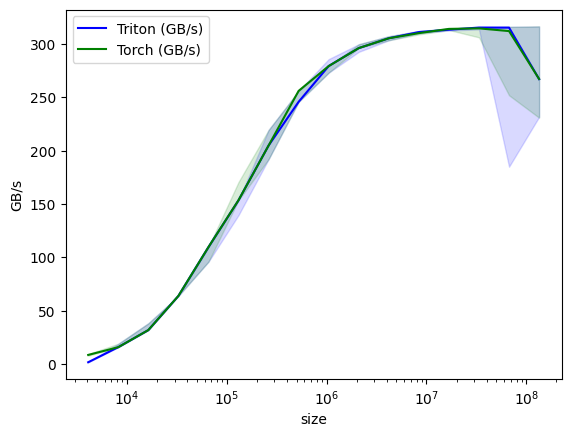

vector-add-performance:
           size  Triton (GB/s)  Torch (GB/s)
0        4096.0       1.882353      8.727273
1        8192.0      15.999999     15.999999
2       16384.0      31.999999     31.999999
3       32768.0      63.999998     63.999998
4       65536.0     109.714284    109.714284
5      131072.0     153.600004    153.600004
6      262144.0     204.800005    204.800005
7      524288.0     245.760006    255.999991
8     1048576.0     279.272725    279.272725
9     2097152.0     296.096389    296.096389
10    4194304.0     305.291919    305.291919
11    8388608.0     311.088617    310.107257
12   16777216.0     313.319519    314.070291
13   33554432.0     315.329604    314.572807
14   67108864.0     315.266384    312.014285
15  134217728.0     267.039732    267.153121


In [23]:
benchmark.run(print_data=True, show_plots=True)